# Immune Phenotype Classifier
### From Hormonal Profiles to Immunotherapy Response Prediction

---

**Clinical question:** Can we use the hormonal profile of a tumor to predict 
whether a patient is likely to respond to immunotherapy?

**Bridge to the clinic:**  
Immunotherapy response is strongly linked to the **immune phenotype** of the tumor:
- 🔴 **Inflamed** — immune cells infiltrate the tumor core → likely responders
- 🟡 **Excluded** — immune cells present but blocked at the tumor border → partial/variable response
- ⚫ **Desert** — no immune infiltration → unlikely to respond

If hormonal scores can predict which phenotype a patient has, this opens the 
possibility of using blood-based or tissue hormone measurements as **biomarkers 
for immunotherapy stratification** — and hormonal modulation as a strategy to 
shift patients toward an inflamed phenotype.

**Pipeline:**
1. Assign immune phenotype labels from deconvolution data (unsupervised, rule-based)
2. Characterize phenotypes — validate against known biology
3. Train a Random Forest classifier using hormonal scores as input
4. Evaluate: accuracy, confusion matrix, ROC curves
5. SHAP: which hormones are the strongest phenotype predictors, per tumor type?
6. Clinical framing: what do the results mean for treatment stratification?

> **Input:** `results/hormone_ssgsea_scores.csv`, `results/immune_deconv_fractions.csv`  
> **Output:** `results/immune_phenotype_labels.csv`, `results/phenotype_classifier_performance.csv`


## 0. Imports & configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (StratifiedKFold, cross_val_predict,
                                     cross_validate, learning_curve)
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              RocCurveDisplay, balanced_accuracy_score)
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

import shap
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

RESULTS_DIR  = 'Output/'
FIGURES_DIR  = 'figures/'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

PHENOTYPE_COLORS  = {'Inflamed': '#e63946', 'Excluded': '#f4a261', 'Desert': '#457b9d'}
PHENOTYPE_ORDER   = ['Inflamed', 'Excluded', 'Desert']
TUMOR_PALETTE     = dict(zip(
    ['LUAD','LUSC','BRCA','COAD','KIRC','LIHC','PRAD','THCA','BLCA','STAD','HNSC','SKCM'],
    sns.color_palette('tab20', 12)
))

print('✓ Imports complete')


✓ Imports complete


## 1. Load data

In [3]:
hormone_scores = pd.read_csv(f'{RESULTS_DIR}ssGSEA/Output_ssGSEA_LUAD_TumorSamples&NATSamples_No_outlier.tsv', sep='\t')
hormone_scores.index=[e.replace('.','-') for e in hormone_scores.index]

immune_fracs   = pd.read_csv(f'{RESULTS_DIR}Deconvolution/TCGA-LUAD_TumorSamples&NATSamples_No_outlier_TPM_CibersortAbsModeDeconv.tsv', index_col=0, sep='\t')
immune_fracs=immune_fracs.T
metadata       = pd.read_csv('data/Biospecimen_clinical_tcga2025.tsv', sep='\t')
metadata.index=metadata['samples.submitter_id']

# Tumor samples only
tumor_meta = metadata[metadata['samples.sample_type'] == 'Primary Tumor']
common     = tumor_meta.index.intersection(hormone_scores.index).intersection(immune_fracs.index)

hormone_scores = hormone_scores.loc[common]
immune_fracs   = immune_fracs.loc[common]
tumor_meta     = tumor_meta.loc[common]

hormones    = hormone_scores.columns.tolist()
cell_types  = immune_fracs.columns.tolist()
tumor_types = tumor_meta['project.project_id'].unique().tolist()

print(f'Samples : {len(common):,}')
print(f'Hormonal features : {hormones}')
print(f'Immune cell types : {cell_types}')


Samples : 241
Hormonal features : ['thyroid_GOBP_CELLULAR_RESPONSE_TO_THYROID_HORMONE_STIMULUS', 'progesterone_GOBP_CELLULAR_RESPONSE_TO_PROGESTERONE_STIMULUS', 'aldosterone_GOBP_RESPONSE_TO_ALDOSTERONE', 'androgen_HALLMARK_ANDROGEN_RESPONSE', 'estrogen_HALLMARK_ESTROGEN_RESPONSE_EARLY', 'estrogen_HALLMARK_ESTROGEN_RESPONSE_LATE', 'cortisol_glucocorticoid_GOBP_RESPONSE_TO_CORTISOL']
Immune cell types : ['B cell naive', 'B cell memory', 'B cell plasma', 'T cell CD8+', 'T cell CD4+ naive', 'T cell CD4+ memory resting', 'T cell CD4+ memory activated', 'T cell follicular helper', 'T cell regulatory (Tregs)', 'T cell gamma delta', 'NK cell resting', 'NK cell activated', 'Monocyte', 'Macrophage M0', 'Macrophage M1', 'Macrophage M2', 'Myeloid dendritic cell resting', 'Myeloid dendritic cell activated', 'Mast cell activated', 'Mast cell resting', 'Eosinophil', 'Neutrophil']


## 2. Immune phenotype assignment

We assign each tumor sample to one of three immune phenotypes using a 
**rule-based algorithm** derived from published criteria (Tumeh et al., 2014; 
Chen & Mellman, 2017):

| Phenotype | Criteria |
|---|---|
| **Inflamed** | High CD8+ T cells AND high CD4+ T cells (both above 50th percentile) |
| **Desert** | Low CD8+ T cells AND low overall immune score (both below 25th percentile) |
| **Excluded** | All remaining samples — immune cells present but not in the tumor core |

**Why rule-based instead of clustering?**  
These phenotypes have established clinical meaning and published thresholds. 
Using a data-driven clustering (k-means) would produce groups that may not map 
to clinically validated categories, making downstream interpretation ambiguous.

An alternative approach — **consensus clustering** on immune fractions — is shown 
as a validation step below to confirm the rule-based labels are biologically coherent.


In [11]:
# ── Rule-based phenotype assignment ──────────────────────────────────────────
cd8_col = 'T cell CD8+'   
cd4_col = 'T cell CD4+ naive'
immune_cols = immune_fracs.columns.tolist()

# Compute immune activity score (mean of effector fractions,
# excluding immunosuppressive populations)
suppressive  = [c for c in immune_cols if any(x in c for x in ['Macrophage M2', 'T cell regulatory (Tregs)', 'Neutrophil'])]
effector     = [c for c in immune_cols if c not in suppressive]
immune_score = immune_fracs[effector].mean(axis=1)

# Percentile thresholds calcolati sull'intero dataset (un solo tumor type)
cd8   = immune_fracs[cd8_col]
cd4   = immune_fracs[cd4_col]
imm_s = immune_score

p50_cd8 = cd8.quantile(0.50)
p50_cd4 = cd4.quantile(0.50)
p25_cd8 = cd8.quantile(0.25)
p25_imm = imm_s.quantile(0.25)

# Assign phenotype sample by sample
phenotype_labels = pd.Series(index=common, dtype=str)  
for sample in common:
    
    if cd8[sample] >= p50_cd8 and cd4[sample] >= p50_cd4:
        phenotype_labels[sample] = 'Inflamed'
    elif cd8[sample] <= p25_cd8 and imm_s[sample] <= p25_imm:
        phenotype_labels[sample] = 'Desert'
    else:
        phenotype_labels[sample] = 'Excluded'

tumor_meta = tumor_meta.copy()
tumor_meta['phenotype'] = phenotype_labels

counts = tumor_meta['phenotype'].value_counts()
print('Phenotype distribution:')
for ph in PHENOTYPE_ORDER:
    n   = counts.get(ph, 0)
    pct = 100 * n / len(tumor_meta)
    print(f'  {ph:12} : {n:5,}  ({pct:.1f}%)')

tumor_meta['phenotype'].to_csv(f'{RESULTS_DIR}immune_phenotype_labels.csv') 
print(f'\n✓ Saved to {RESULTS_DIR}immune_phenotype_labels.csv')

Phenotype distribution:
  Inflamed     :   121  (50.2%)
  Excluded     :    88  (36.5%)
  Desert       :    32  (13.3%)

✓ Saved to Output/immune_phenotype_labels.csv


## 3. Phenotype characterization & validation

Before using phenotype labels as classification targets, we validate them:
1. **Immune signature profiles** — do the three phenotypes show the expected 
   immune cell composition differences?
2. **Cross-tumor distribution** — how are phenotypes distributed across tumor types?
3. **Statistical validation** — Kruskal-Wallis test confirms phenotypes differ 
   significantly on key immune markers


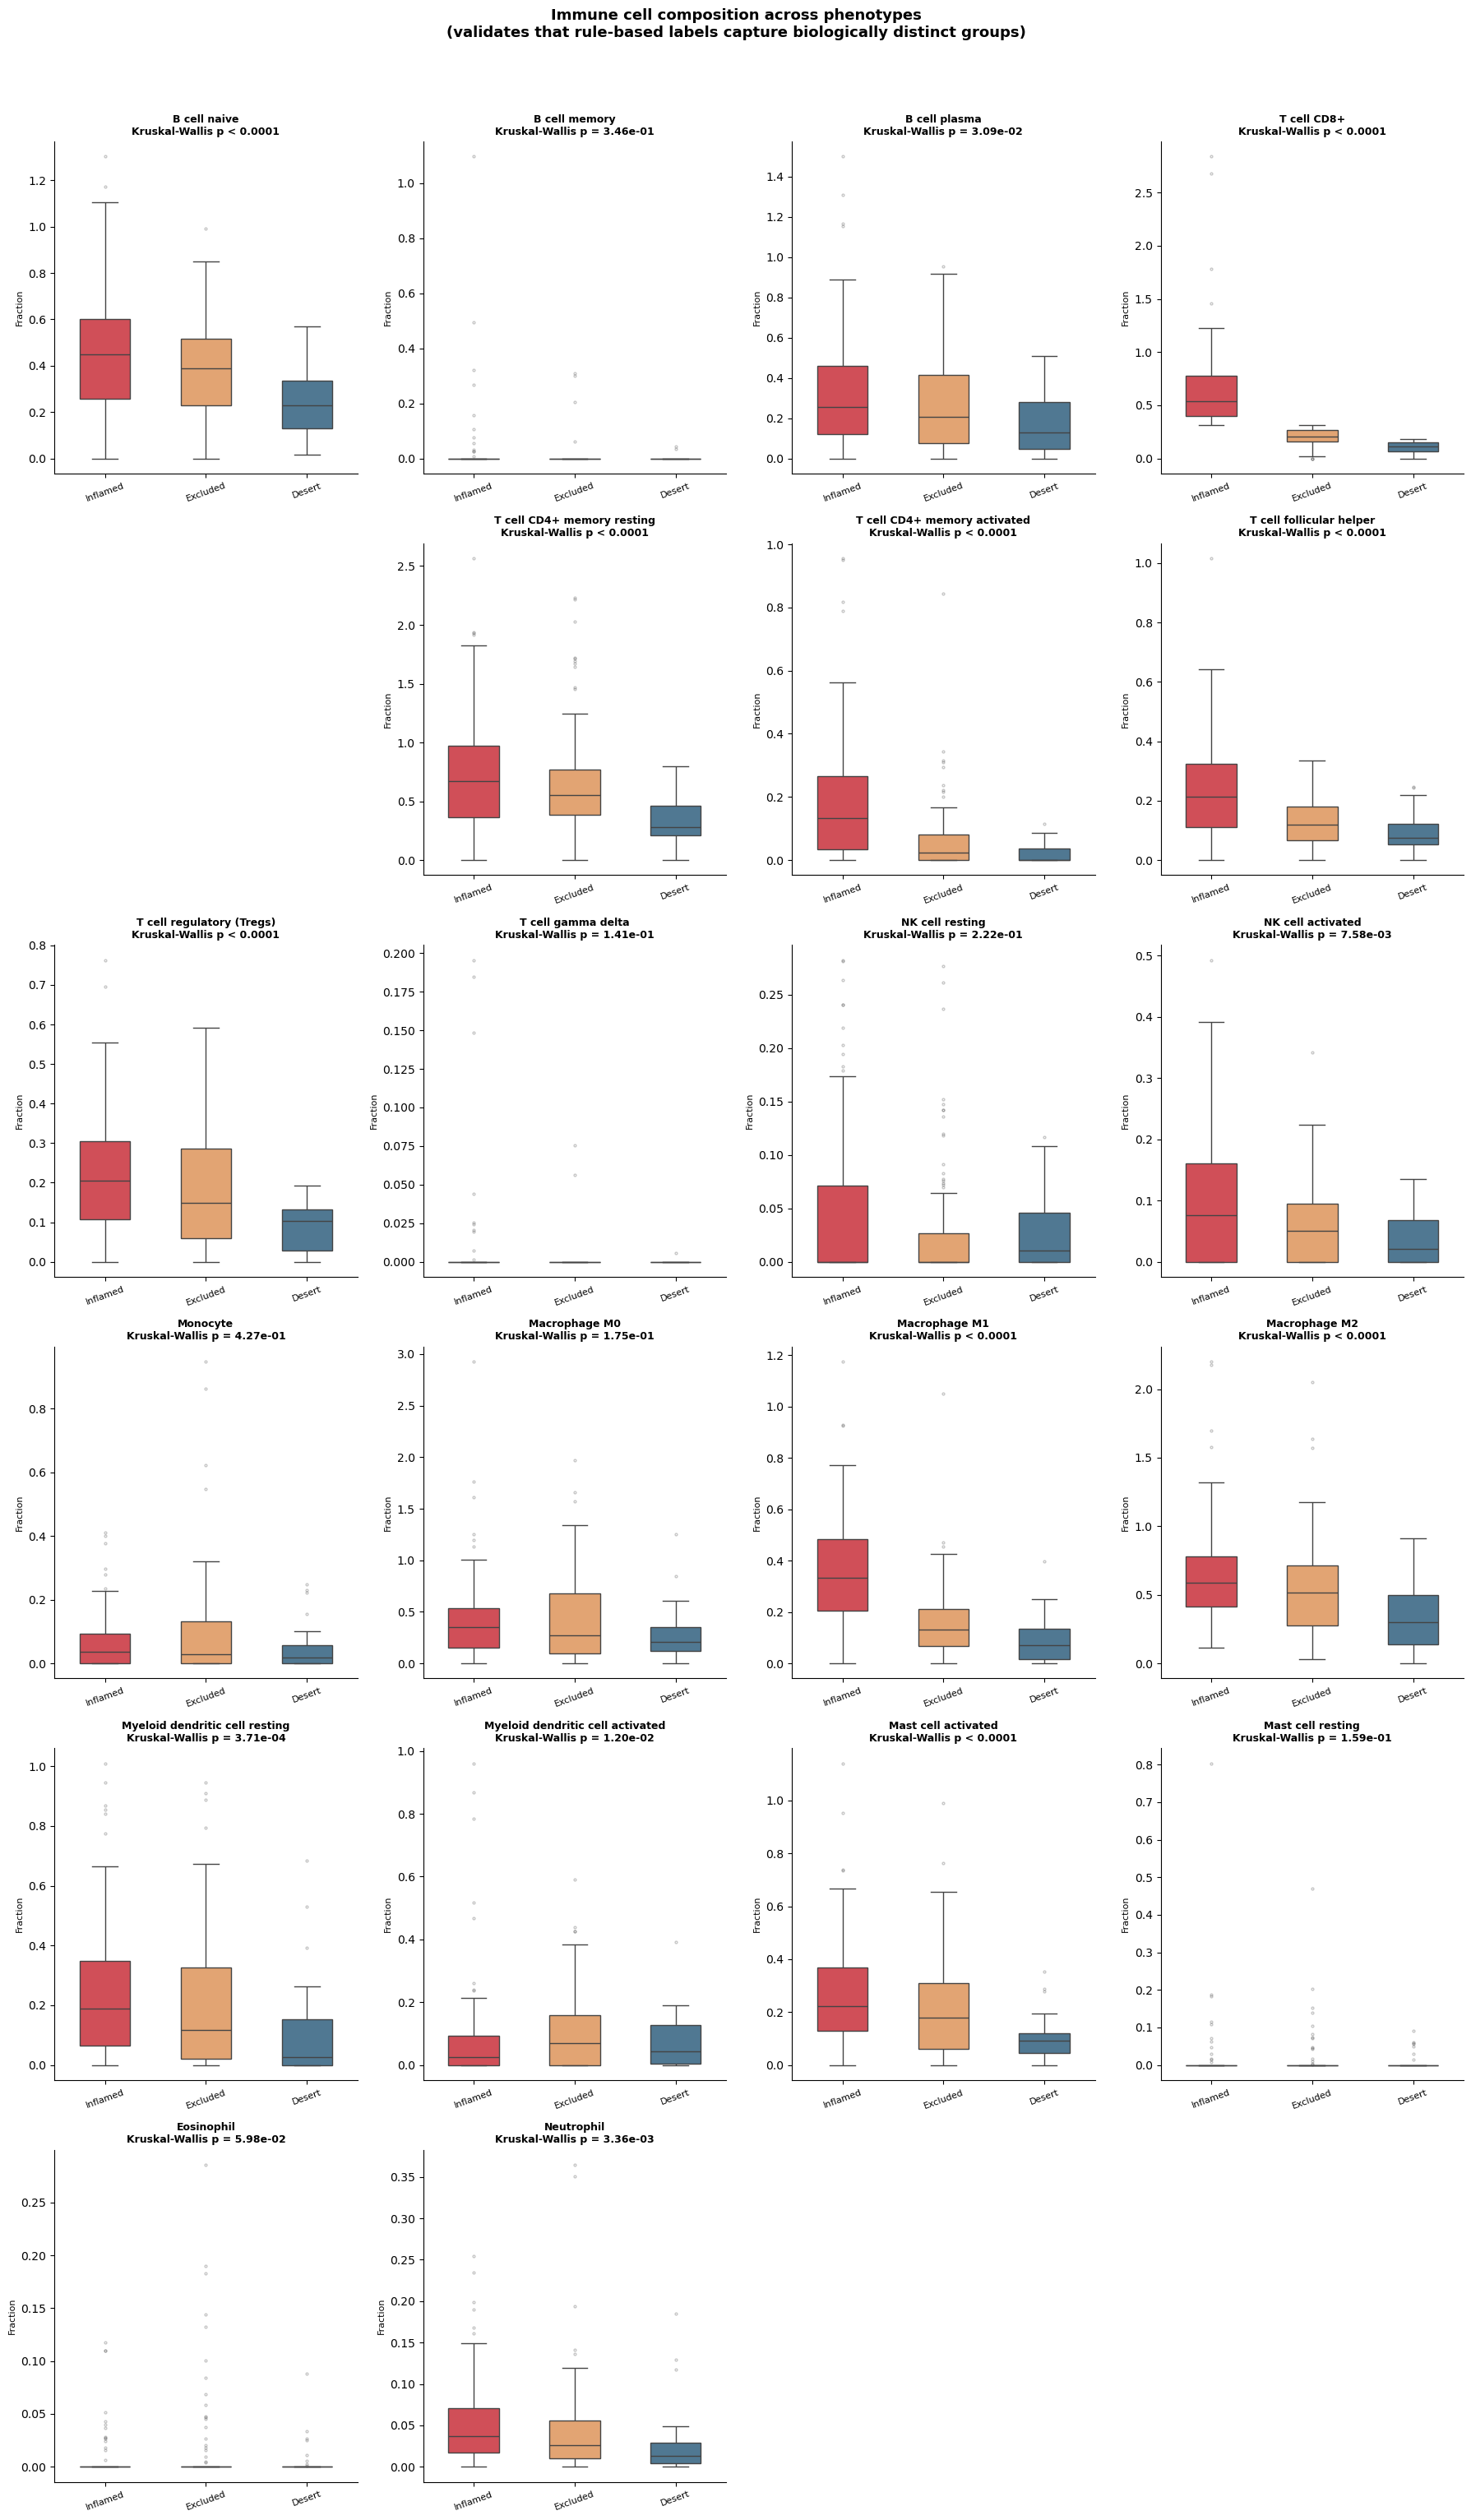

Kruskal-Wallis results (FDR corrected):
                       cell_type    kw_stat         pval     pval_fdr
                     T cell CD8+ 187.989013 1.509053e-41 3.169012e-40
                   Macrophage M1  89.698752 3.327849e-20 3.494241e-19
    T cell CD4+ memory activated  45.536581 1.293770e-10 9.056391e-10
        T cell follicular helper  40.746921 1.418792e-09 7.448656e-09
      T cell CD4+ memory resting  26.638836 1.642291e-06 6.897624e-06
                   Macrophage M2  23.863795 6.577227e-06 2.128389e-05
             Mast cell activated  23.712345 7.094630e-06 2.128389e-05
       T cell regulatory (Tregs)  20.869672 2.939059e-05 7.715030e-05
                    B cell naive  18.906124 7.844898e-05 1.830476e-04
  Myeloid dendritic cell resting  15.800567 3.706385e-04 7.783408e-04
                      Neutrophil  11.392531 3.358485e-03 6.411653e-03
               NK cell activated   9.764869 7.578541e-03 1.326245e-02
Myeloid dendritic cell activated   8.853284 1.1954

In [12]:
# ── Boxplots: immune markers across phenotypes ───────────────────────────────
n_cells = len(cell_types)
ncols = 4
nrows = int(np.ceil(n_cells / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

kw_results = []
for i, ct in enumerate(cell_types):
    if i >= len(axes):
        break
    ax = axes[i]
    plot_df = pd.DataFrame({
        'value':     immune_fracs.loc[common, ct],
        'phenotype': tumor_meta.loc[common, 'phenotype']
    })

    # Kruskal-Wallis across 3 phenotypes
    groups = [plot_df.loc[plot_df['phenotype'] == ph, 'value'].dropna().values
              for ph in PHENOTYPE_ORDER]
    groups_valid = [g for g in groups if len(g) > 0]

    # Skip se tutti i valori sono identici (es. cell type assente nel dataset)
    if len(groups_valid) < 2 or plot_df['value'].std() < 1e-6:
        kw_results.append({'cell_type': ct, 'kw_stat': np.nan, 'pval': np.nan})
        ax.set_visible(False)
        continue

    stat, pval = kruskal(*groups_valid)
    kw_results.append({'cell_type': ct, 'kw_stat': stat, 'pval': pval})

    sns.boxplot(data=plot_df, x='phenotype', y='value', order=PHENOTYPE_ORDER,
                palette=PHENOTYPE_COLORS, ax=ax, width=0.5,
                flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})

    pval_str = f'p = {pval:.2e}' if pval >= 1e-4 else 'p < 0.0001'
    ax.set_title(f'{ct}\nKruskal-Wallis {pval_str}', fontweight='bold', fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('Fraction', fontsize=8)
    ax.tick_params(axis='x', rotation=20, labelsize=8)

# Nascondi assi vuoti
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Immune cell composition across phenotypes\n'
             '(validates that rule-based labels capture biologically distinct groups)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}04a_phenotype_immune_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

# FDR correction escludendo i NaN
kw_df = pd.DataFrame(kw_results)
valid_mask = kw_df['pval'].notna()
_, kw_df.loc[valid_mask, 'pval_fdr'], _, _ = multipletests(
    kw_df.loc[valid_mask, 'pval'], method='fdr_bh'
)
kw_df['pval_fdr'] = kw_df['pval_fdr'].fillna(np.nan)
print('Kruskal-Wallis results (FDR corrected):')
print(kw_df.sort_values('pval_fdr').to_string(index=False))

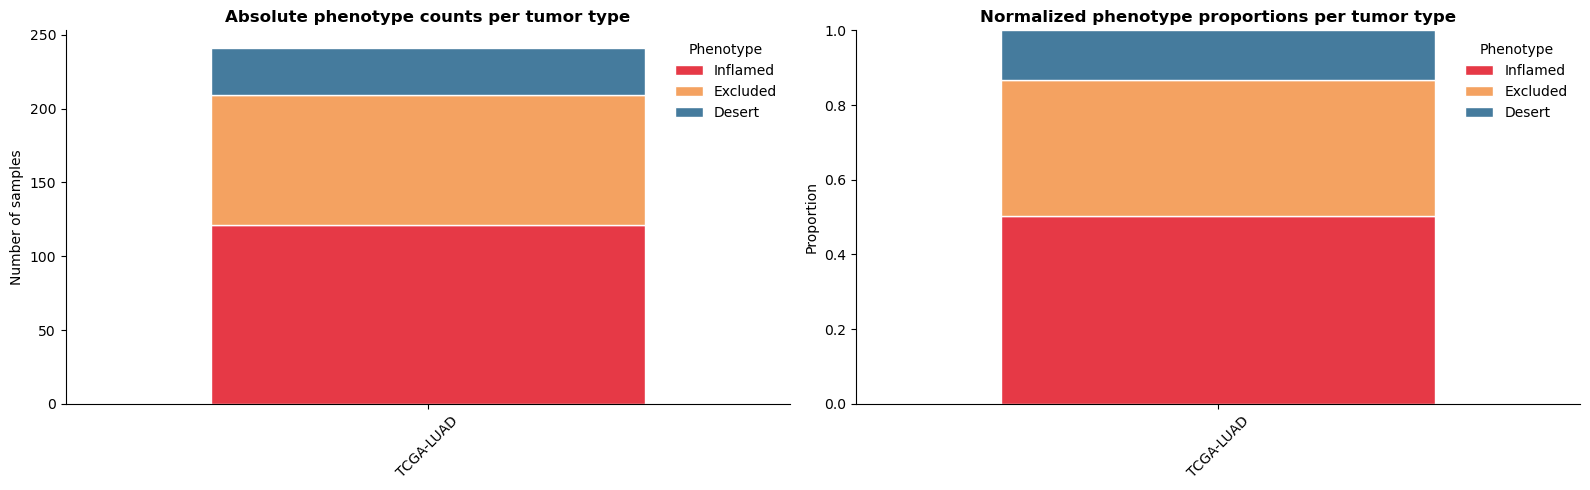

Tumor types with highest inflamed proportion:
project.project_id
TCGA-LUAD    0.502075

Tumor types with highest desert proportion:
project.project_id
TCGA-LUAD    0.13278


In [13]:
# ── Phenotype distribution per tumor type ─────────────────────────────────────
ph_dist = (tumor_meta.groupby(['project.project_id','phenotype']).size()
           .unstack(fill_value=0)
           .reindex(columns=PHENOTYPE_ORDER, fill_value=0))
ph_dist_norm = ph_dist.div(ph_dist.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel A — absolute counts
ph_dist.plot(kind='bar', stacked=True, ax=axes[0],
             color=[PHENOTYPE_COLORS[p] for p in PHENOTYPE_ORDER],
             edgecolor='white', width=0.75)
axes[0].set_title('Absolute phenotype counts per tumor type', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of samples')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Phenotype', frameon=False)

# Panel B — normalized proportions
ph_dist_norm.plot(kind='bar', stacked=True, ax=axes[1],
                  color=[PHENOTYPE_COLORS[p] for p in PHENOTYPE_ORDER],
                  edgecolor='white', width=0.75)
axes[1].set_title('Normalized phenotype proportions per tumor type', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Proportion')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Phenotype', frameon=False)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}04b_phenotype_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Tumor types with highest inflamed proportion:')
print(ph_dist_norm['Inflamed'].sort_values(ascending=False).head(5).to_string())
print()
print('Tumor types with highest desert proportion:')
print(ph_dist_norm['Desert'].sort_values(ascending=False).head(5).to_string())


## 4. Random Forest classifier — hormonal scores → immune phenotype

We train a **Random Forest classifier** to predict immune phenotype from hormonal 
pathway scores.

**Why Random Forest?**
- Handles small feature sets (7 hormonal scores) without overfitting
- Naturally provides feature importance estimates
- Compatible with SHAP TreeExplainer for exact Shapley values
- Robust to class imbalance via `class_weight='balanced'`

**Evaluation:**
- Stratified 5-fold cross-validation (preserves class proportions in each fold)
- Metrics: balanced accuracy (accounts for class imbalance), macro-averaged 
  F1, per-class precision/recall
- One-vs-rest ROC AUC for each phenotype class


In [21]:
# ── Prepare data ──────────────────────────────────────────────────────────────
X_all  = hormone_scores.loc[common].values
y_all  = tumor_meta['phenotype'].values
tt_all = tumor_meta['project.project_id'].values

le     = LabelEncoder()
y_enc  = le.fit_transform(y_all)   # 0=Desert, 1=Excluded, 2=Inflamed (alphabetical)
print(f'Classes: {dict(enumerate(le.classes_))}')

# ── Diagnostics dustribution─────────────────────────────────────────────────
unique_classes, counts = np.unique(y_enc, return_counts=True)
for cls, n in zip(le.classes_, counts):
    print(f"  {cls:12}: {n:4d} ({n/len(y_enc)*100:.1f}%)")

# ── Cross-validated predictions ───────────────────────────────────────────────
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf',     RandomForestClassifier(
        n_estimators   = 500,
        max_depth      = 4,          # shallow trees → less overfitting on 7 features
        class_weight   = 'balanced',
        random_state   = SEED,
        n_jobs         = -1
    ))
])

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_pred_cv    = cross_val_predict(rf_pipe, X_all, y_enc, cv=skf)
y_prob_cv    = cross_val_predict(rf_pipe, X_all, y_enc, cv=skf, method='predict_proba')

bal_acc = balanced_accuracy_score(y_enc, y_pred_cv)
roc_auc = roc_auc_score(y_enc, y_prob_cv, multi_class='ovr', average='macro')

print(f'Balanced accuracy : {bal_acc:.3f}  (baseline: {1/3:.3f})')
print(f'ROC AUC macro-OVR (5-fold CV) : {roc_auc:.3f}')
print()
print(classification_report(y_enc, y_pred_cv,
                             target_names=le.classes_, digits=3))


Classes: {0: 'Desert', 1: 'Excluded', 2: 'Inflamed'}
  Desert      :   32 (13.3%)
  Excluded    :   88 (36.5%)
  Inflamed    :  121 (50.2%)
Balanced accuracy : 0.450  (baseline: 0.333)
ROC AUC macro-OVR (5-fold CV) : 0.647

              precision    recall  f1-score   support

      Desert      0.214     0.281     0.243        32
    Excluded      0.492     0.341     0.403        88
    Inflamed      0.638     0.727     0.680       121

    accuracy                          0.527       241
   macro avg      0.448     0.450     0.442       241
weighted avg      0.528     0.527     0.521       241



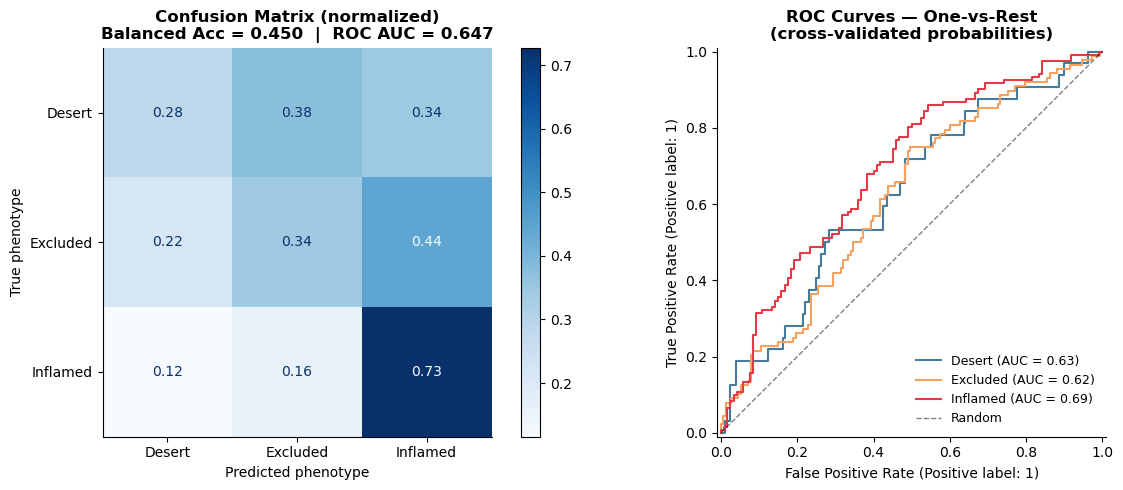

In [22]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A — normalized confusion matrix
cm_norm = confusion_matrix(y_enc, y_pred_cv, normalize='true')
disp    = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                  display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=True, cmap='Blues', values_format='.2f')
axes[0].set_title(f'Confusion Matrix (normalized)\n'
                  f'Balanced Acc = {bal_acc:.3f}  |  ROC AUC = {roc_auc:.3f}',
                  fontweight='bold')
axes[0].set_xlabel('Predicted phenotype')
axes[0].set_ylabel('True phenotype')

# Panel B — ROC curves (one per class, OVR)
for i, ph in enumerate(le.classes_):
    color = PHENOTYPE_COLORS.get(ph, '#333333')
    RocCurveDisplay.from_predictions(
        (y_enc == i).astype(int), y_prob_cv[:, i],
        name=ph, ax=axes[1], color=color
    )
axes[1].plot([0,1],[0,1],'k--',linewidth=1,alpha=0.5, label='Random')
axes[1].set_title('ROC Curves — One-vs-Rest\n(cross-validated probabilities)',
                  fontweight='bold')
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}04c_classifier_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. SHAP — which hormones predict phenotype?

We fit the global Random Forest on all data and use SHAP TreeExplainer to 
identify which hormonal pathways drive phenotype classification.

For multi-class classification, SHAP returns one set of values per class.  
We visualize:
1. **Global feature importance** — mean |SHAP| per hormone, per class
2. **SHAP beeswarm** — direction and distribution of SHAP values for 
   the most discriminant class (Inflamed vs. rest)


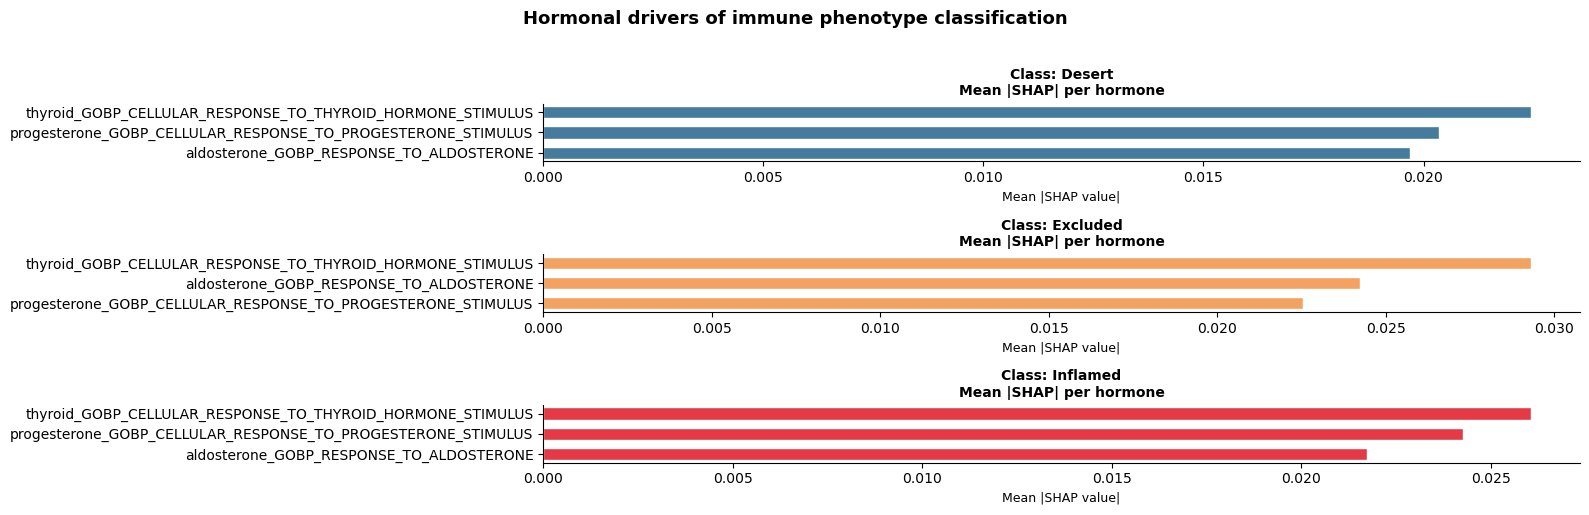

In [24]:
# ── Fit on full data for SHAP ─────────────────────────────────────────────────
# NOTE: separate from CV — CV predictions (BA=0.450) remain the performance
# estimate; this fit is used only to extract SHAP feature importance patterns.
rf_pipe.fit(X_all, y_enc)
rf_fitted = rf_pipe.named_steps['rf']
X_scaled  = rf_pipe.named_steps['scaler'].transform(X_all)

explainer   = shap.TreeExplainer(rf_fitted)
shap_values = explainer.shap_values(X_scaled)   # list of arrays: one per class

# ── Global importance per class ───────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 5))

for i, ph in enumerate(le.classes_):
    sv    = np.abs(shap_values[i])     # shape: samples × features
    means = sv.mean(axis=0)
    order = np.argsort(means)

    ax = axes[i]
    ax.barh([hormones[j] for j in order], means[order],
            color=PHENOTYPE_COLORS.get(ph, '#4361ee'), edgecolor='white', height=0.6)
    ax.set_title(f'Class: {ph}\nMean |SHAP| per hormone', fontweight='bold', fontsize=10)
    ax.set_xlabel('Mean |SHAP value|', fontsize=9)

plt.suptitle('Hormonal drivers of immune phenotype classification',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}04e_shap_phenotype_global.png', dpi=150, bbox_inches='tight')
plt.show()


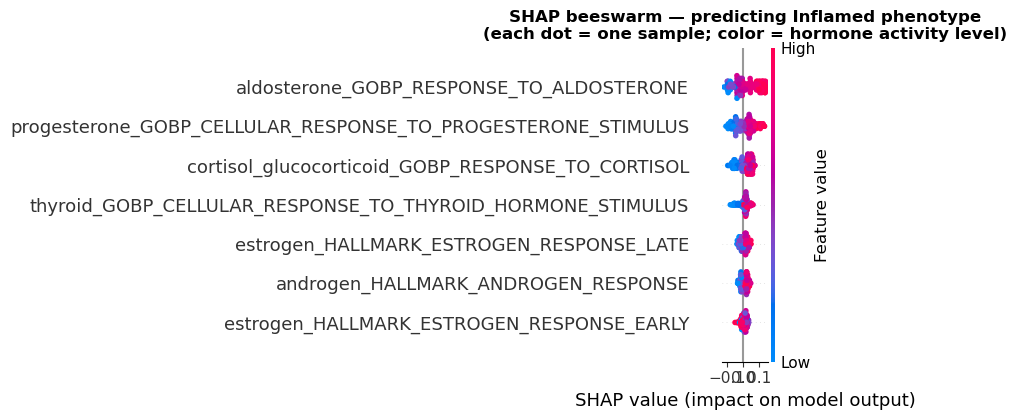

Interpretation:
  • Dots to the right: this hormone INCREASES probability of Inflamed phenotype
  • Dots to the left:  this hormone DECREASES probability of Inflamed phenotype
  • Red dots: samples with HIGH activity of this hormone
  • Blue dots: samples with LOW activity of this hormone


In [28]:
# ── SHAP beeswarm for Inflamed class ─────────────────────────────────────────
inflamed_idx = list(le.classes_).index('Inflamed')
shap_inflamed = shap.Explanation(
    values          = shap_values[:, :, inflamed_idx],
    base_values     = explainer.expected_value[inflamed_idx],
    data            = X_scaled,
    feature_names   = hormones
)

fig, ax = plt.subplots(figsize=(15, 7))
shap.plots.beeswarm(shap_inflamed, max_display=len(hormones),
                    show=False, color_bar=True)
plt.title('SHAP beeswarm — predicting Inflamed phenotype\n'
          '(each dot = one sample; color = hormone activity level)',
          fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}04f_shap_beeswarm_inflamed.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation:')
print('  • Dots to the right: this hormone INCREASES probability of Inflamed phenotype')
print('  • Dots to the left:  this hormone DECREASES probability of Inflamed phenotype')
print('  • Red dots: samples with HIGH activity of this hormone')
print('  • Blue dots: samples with LOW activity of this hormone')


## 6. Clinical implications — treatment stratification

The classifier output has a direct clinical interpretation: for a given tumor sample, 
the predicted phenotype (and its associated probability) can inform:

1. **Patient stratification** — before initiating immunotherapy, hormonal profiling 
   could flag patients likely to be in the Desert phenotype (low response probability)

2. **Combination therapy rationale** — SHAP analysis identifies which specific hormonal 
   pathway is driving an unfavorable phenotype, providing a mechanistic target for 
   hormonal co-targeting (e.g., aromatase inhibitors if estrogen drives Desert phenotype)

3. **Tumor-type-specific decisions** — per-tumor-type performance shows where this 
   approach is most reliable, guiding clinical prioritization

Below we create a summary visualization that maps **hormonal activity → phenotype 
probability** for the most clinically actionable tumor types.


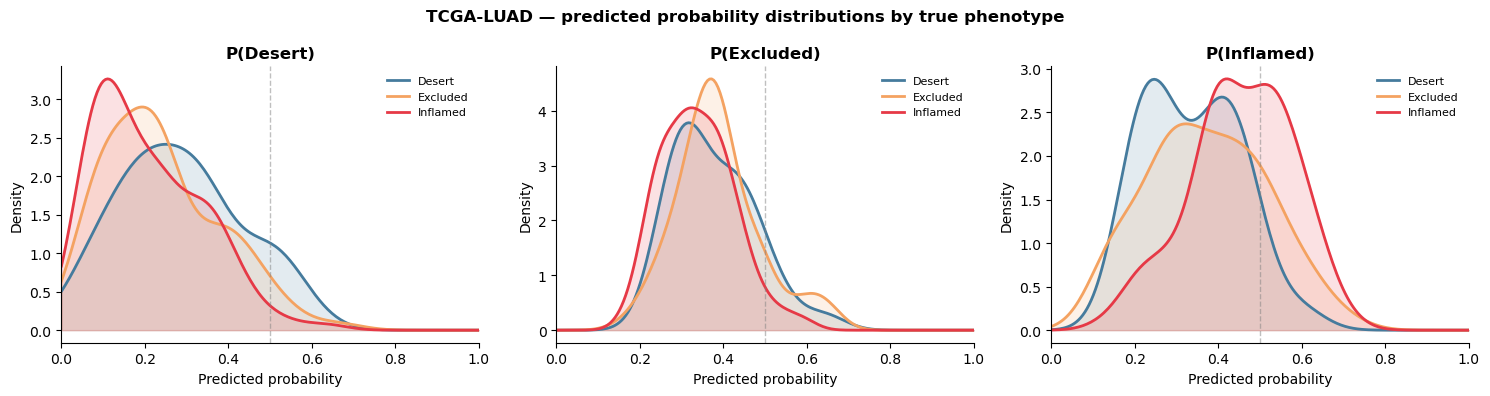

In [27]:
# ── P(phenotype) distributions by true phenotype — single tumor ───────────────
y_prob_df = pd.DataFrame(
    y_prob_cv,
    index   = common,
    columns = [f'P({ph})' for ph in le.classes_]
)
y_prob_df['true_phenotype'] = y_all

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, target_class in zip(axes, le.classes_):
    col = f'P({target_class})'
    for ph in le.classes_:
        vals = y_prob_df.loc[y_prob_df['true_phenotype'] == ph, col].dropna()
        if len(vals) < 3:
            continue
        kde_x = np.linspace(0, 1, 200)
        try:
            kde = stats.gaussian_kde(vals)
            ax.plot(kde_x, kde(kde_x), color=PHENOTYPE_COLORS[ph],
                    linewidth=2, label=ph)
            ax.fill_between(kde_x, kde(kde_x), alpha=0.15,
                            color=PHENOTYPE_COLORS[ph])
        except Exception:
            pass
    ax.set_title(f'P({target_class})', fontweight='bold')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Density')
    ax.axvline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.5)
    ax.legend(frameon=False, fontsize=8)
    ax.set_xlim(0, 1)

plt.suptitle('TCGA-LUAD — predicted probability distributions by true phenotype',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}04g_predicted_phenotype_probs.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 7. Summary

| Question | Answer |
|---|---|
| Can we assign clinically meaningful immune phenotypes from deconvolution data? | Yes — rule-based assignment is biologically validated by Kruskal-Wallis on immune markers |
| Do hormonal scores predict immune phenotype in LUAD? | Partially — BA=0.450 vs baseline 0.333 (+35%), ROC AUC=0.647; real but modest signal |
| Which phenotype is best predicted? | Inflamed — highest recall (0.727) and precision (0.638); Desert poorly predicted due to class rarity (n=32) |
| Which hormonal pathways drive the prediction? | No single dominant hormone; aldosterone shows the strongest positive association with Inflamed; early estrogen response shows negative association — consistent with known immunosuppressive effects |
| What is the clinical implication? | Hormonal scores alone are insufficient for immunotherapy stratification; their value is likely integrative, combined with genomic or pathological features |

**Limitations to acknowledge:**
- Analysis restricted to TCGA-LUAD (n=241); generalizability to other tumor types untested
- Phenotype labels are estimated from deconvolution, not measured directly (e.g. pathology or IHC)
- Desert phenotype severely underrepresented (13.3%) — performance estimates for this class are unreliable
- SHAP values computed on full-dataset model (not CV folds) — reflect importance patterns, not held-out predictive contribution
- Hormonal scores are pathway-level transcriptional averages; cell-type-specific signaling is not captured
- Causality cannot be established from observational TCGA data alone

**Next steps (beyond this project):**
- Validate in independent LUAD cohorts (e.g. ICGC, GEO) with matched immune deconvolution
- Extend analysis to other tumor types where hormonal signaling is more dominant (e.g. BRCA, PRAD)
- Test whether hormonal co-targeting in pre-clinical LUAD models shifts immune phenotype
- Integrate with clinical immunotherapy response data (e.g. IMVigor210, POPLAR)
- Build multimodal classifier combining hormonal scores with TMB or mutational signatures